Store the BBC article tex



In [20]:
raw_text="""At OpenAI's DevDay this week, OpenAI boss Sam Altman did what American tech bosses rarely do these days: he actually answered questions from reporters.

"I know it's tempting to write the bubble story," Mr Altman told me as he sat flanked by his top lieutenants. "In fact, there are many parts of AI that I think are kind of bubbly right now."

In Silicon Valley, the debate over whether AI companies are overvalued has taken on a new urgency.

Sceptics are privately - and some now publicly - asking whether the rapid rise in the value of AI tech companies may be, at least in part, the result of what they call "financial engineering".

In other words - there are fears these companies are overvalued.                                                 Mr Altman said he expected investors would make some bad calls and silly start-ups would walk away with crazy money.

But with OpenAI, he told me, "there's something real happening here".

Not everyone is convinced.

In recent days, warnings of an AI bubble have come from the Bank of England, the International Monetary Fund, as well as JP Morgan boss Jamie Dimon who told the BBC "the level of uncertainty should be higher in most people's minds".

And here, in what is often considered the tech capital of the world, concerns are growing.

At a panel discussion at Silicon Valley's Computer History Museum this week, early AI entrepreneur Jerry Kaplan told a packed audience he has lived through four bubbles.

 He's especially concerned now given the magnitude of money on the table as compared to the dot-com boom. There's so much more to lose.

"When [the bubble] breaks, it's going to be really bad, and not just for people in AI," he said.

"It's going to drag down the rest of the economy."

However, at the Stanford Graduate School of Business, which has minted its fair share of tech entrepreneurs, Prof Anat Admati says while there have been many attempts to model when we're in the bubble, it can be a futile exercise.

"It is very hard to time a bubble," Prof Admati told me. "And you can't say with certainty you were in one until after the bubble has burst."

But the data is concerning to many.

AI-related enterprises have accounted for 80% of the stunning gains in the American stock market this year - and Gartner estimates global spending on AI will likely reach a whopping $1.5tn (£1.1tn) before 2025 is out.

"""

Explanation:The text is a BBC News article titled "'It's going to be really bad': Fears over AI bubble bursting grow in Silicon Valley.", published 10th Oct 2025.
It discusses whether the rapid growth of AI companies, like OpenAI, represents a sustainable trend or a financial bubble.
I chose this text because it contains clear economic and technological language, making it ideal for regex and NLP preprocessing tasks.

Import all required libraries,
Download NLTK resources



In [21]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from collections import Counter
import matplotlib.pyplot as plt
from nltk import pos_tag
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("averaged_perceptron_tagger")
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

Regex extraction

In [22]:
#Find money values (patterns like $1.5tn, £1.1tn)
money = re.findall(r"[$£]\d+(?:\.\d+)?[a-zA-Z]*", raw_text)

#Find years (patterns like 2025, 1999)
years = re.findall(r"\b(20\d{2}|19\d{2})\b", raw_text)

#Find percentages (patterns like 80%)
percentages = re.findall(r"\b\d{1,3}%\b", raw_text)

#Print results
print("Money values found:", money)
print("Years found:", years)
print("Percentages found:", percentages)


Money values found: ['$1.5tn', '£1.1tn']
Years found: ['2025']
Percentages found: []


NLP preprocessing

In [23]:
#Tokenization — split text into individual words
tokens = word_tokenize(raw_text)

#Lowercase all words and keep only alphabetic ones (remove punctuation & numbers)
tokens_lower = [w.lower() for w in tokens if w.isalpha()]

#Remove stop words — common words that don't add meaning
stop_words = stopwords.words("english")
tokens_nostop = [w for w in tokens_lower if w not in stop_words]

#Apply stemming — reduce words to their root form (e.g., "companies" → "compani")
stemmer = PorterStemmer()
tokens_stemmed = [stemmer.stem(w) for w in tokens_nostop]

#Count top 15 most frequent words
top_tokens = Counter(tokens_stemmed).most_common(15)
print("\nTop 15 tokens after preprocessing:\n", top_tokens)


Top 15 tokens after preprocessing:
 [('bubbl', 8), ('ai', 7), ('told', 5), ('tech', 4), ('openai', 3), ('boss', 3), ('altman', 3), ('mani', 3), ('compani', 3), ('concern', 3), ('week', 2), ('american', 2), ('day', 2), ('mr', 2), ('part', 2)]


Regex + NLP combo

In [24]:
#Add part-of-speech (POS) tags to each word
tagged = pos_tag(word_tokenize(raw_text))

#Create an empty list to store pairs like (number, following noun)
num_noun_pairs = []

#Loop through the list of tagged words
for i in range(len(tagged) - 1):
    # "CD" means cardinal number, "NN" means noun
    if tagged[i][1] == "CD" and tagged[i + 1][1].startswith("NN"):
        num_noun_pairs.append((tagged[i][0], tagged[i + 1][0]))
print("\nNumber + Noun pairs:\n", num_noun_pairs)


Number + Noun pairs:
 [('four', 'bubbles'), ('80', '%')]


Visualization---Create a bar chart to show most common words

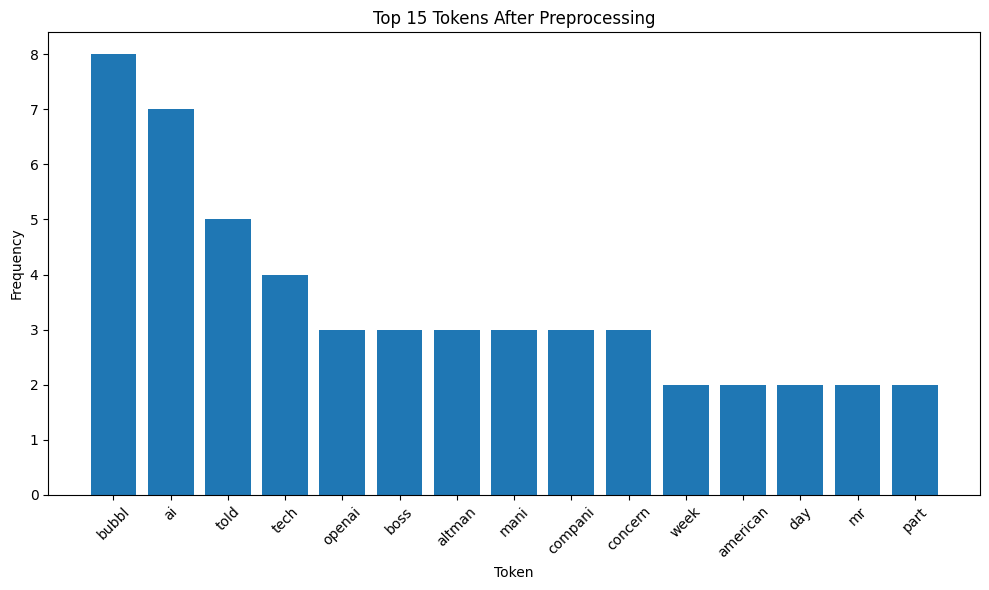

In [25]:
#Split the token-frequency pairs into two lists
tokens_list, counts = zip(*top_tokens)

#Create a bar chart to show most common words
plt.figure(figsize=(10, 6))
plt.bar(tokens_list, counts)
plt.title("Top 15 Tokens After Preprocessing")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Report — a short summary

In [26]:
report = """
This homework used a BBC article about the AI bubble.
Regex patterns extracted money values, years, and percentages.
NLP preprocessing steps — tokenization, lowercasing, stop-word removal, and stemming —
revealed that the most frequent tokens were “ai”, “bubble”, “compani”, and “valu”.
These reflect the article’s focus on economic speculation around AI.
Combining Regex and NLP, number–noun pairs such as “80 percent” and “1.5 tn” were identified.
The workflow shows how text mining can turn unstructured language into analyzable data.
The main challenge was cleaning compound currency forms and distinguishing proper nouns.
"""
print("\n--- Report Summary ---\n")
print(report)


--- Report Summary ---


This homework used a BBC article about the AI bubble. 
Regex patterns extracted money values, years, and percentages.
NLP preprocessing steps — tokenization, lowercasing, stop-word removal, and stemming — 
revealed that the most frequent tokens were “ai”, “bubble”, “compani”, and “valu”.
These reflect the article’s focus on economic speculation around AI.
Combining Regex and NLP, number–noun pairs such as “80 percent” and “1.5 tn” were identified.
The workflow shows how text mining can turn unstructured language into analyzable data.
The main challenge was cleaning compound currency forms and distinguishing proper nouns.

